In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from math import radians

In [16]:
df = pd.read_csv('../data/listings_clean.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,picture_url,host_id,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_log
0,23986,https://www.airbnb.com/rooms/23986,20250922033939,2025-09-24,city scrape,""" Characteristic Milanese flat""",https://a0.muscache.com/pictures/623d63f8-56cf...,95941,https://www.airbnb.com/users/show/95941,Jeremy,...,4.73,4.69,4.46,f,1,1,0,0,0.16,5.198497
1,46536,https://www.airbnb.com/rooms/46536,20250922033939,2025-09-24,city scrape,Nico & Cinzia's Pink Suite!,https://a0.muscache.com/pictures/4eb8e0f5-e17b...,138683,https://www.airbnb.com/users/show/138683,Nico&Cinzia,...,4.92,4.34,4.58,f,1,1,0,0,0.23,4.465908
2,84741,https://www.airbnb.com/rooms/84741,20250922033939,2025-09-24,city scrape,Nice room with private bathroom,https://a0.muscache.com/pictures/0b34089b-4d58...,443989,https://www.airbnb.com/users/show/443989,Francesca,...,4.88,4.18,4.64,f,3,1,2,0,3.94,3.610918
3,88130,https://www.airbnb.com/rooms/88130,20250922033939,2025-09-24,city scrape,Great comfortable & quite APT. x 4 people!,https://a0.muscache.com/pictures/606790/408e10...,481475,https://www.airbnb.com/users/show/481475,Cinzia,...,5.00,4.43,4.71,f,1,1,0,0,0.04,5.525453
4,101087,https://www.airbnb.com/rooms/101087,20250922033939,2025-09-22,city scrape,"Flat "" Chiesa Rossa2 in Milan",https://a0.muscache.com/pictures/2873561/d13d3...,530151,https://www.airbnb.com/users/show/530151,Vincenzo,...,4.88,4.75,4.63,t,1,1,0,0,0.05,4.394449


## Calculating distante to Duomo

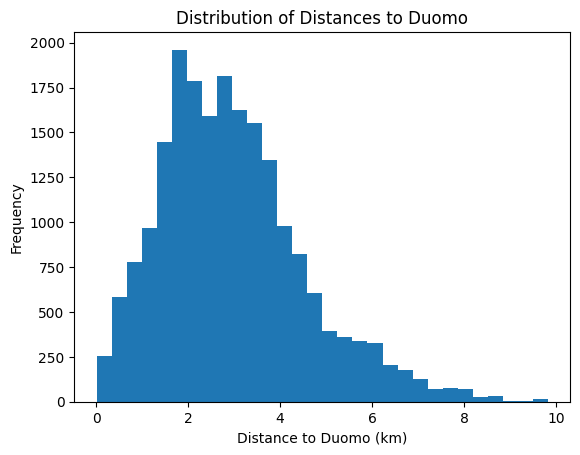


Closest listing to Duomo: 0.019 km
Furthest listing: 9.82 km


In [18]:
duomo_lat = 45.46425
duomo_lan = 9.19179

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_to_duomo_km'] = haversine_km(df['latitude'].values, df['longitude'].values, duomo_lat, duomo_lan)

plt.hist(df['distance_to_duomo_km'], bins=30)
plt.xlabel('Distance to Duomo (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances to Duomo')
plt.show()

print(f"\nClosest listing to Duomo: {df['distance_to_duomo_km'].min():.3f} km")
print(f"Furthest listing: {df['distance_to_duomo_km'].max():.2f} km")


## Neighborhood encoding(convert strings into a single meaningful number)

In [27]:
neighbourhood_medians = df.groupby('neighbourhood_cleansed')['price_log'].median()
df['neighbourhood_encoded'] = df['neighbourhood_cleansed'].map(neighbourhood_medians)

print("\nTop 10 most expensive neighborhoods (by median price):")
print(
    neighbourhood_medians
    .sort_values(ascending=False)
    .head(10)
    .apply(lambda x: f"${np.expm1(x):.0f}/night median")  # back from log
)
print(neighbourhood_medians.nlargest(10))


Top 10 most expensive neighborhoods (by median price):
neighbourhood_cleansed
DUOMO                     $252/night median
SACCO                     $222/night median
BRERA                     $209/night median
GUASTALLA                 $178/night median
MAGENTA - S. VITTORE      $171/night median
GIARDINI PORTA VENEZIA    $167/night median
GARIBALDI REPUBBLICA      $163/night median
VIGENTINA                 $155/night median
PAGANO                    $148/night median
CANTALUPA                 $148/night median
Name: price_log, dtype: object
neighbourhood_cleansed
DUOMO                     5.533389
SACCO                     5.408367
BRERA                     5.347108
GUASTALLA                 5.187386
MAGENTA - S. VITTORE      5.147494
GIARDINI PORTA VENEZIA    5.123964
GARIBALDI REPUBBLICA      5.102906
VIGENTINA                 5.049856
PAGANO                    5.003946
CANTALUPA                 5.002232
Name: price_log, dtype: float64


## Identifying amenities with a significant impact on pricing

In [29]:
import ast
from scipy import stats

def parse_amenities(amenity_str):
    try:
        return ast.literal_eval(amenity_str)
    except (ValueError, SyntaxError):
        return []
    
df['amenities_list'] = df['amenities'].apply(parse_amenities)
df['amenities_count'] = df['amenities_list'].apply(len)

In [32]:
all_amenities = set()
df['amenities_list'].apply(all_amenities.update)
print(f'Total unique amenities: {len(all_amenities)}')

Total unique amenities: 4080


### Do listings with this amenity have significantly higher prices?

In [33]:
# Test: Mann-Whitney U for each amenity

results = []

for amenity in all_amenities:
    has_amenity = df[df['amenities_list'].apply(lambda lst: amenity in lst)]['price_log']
    no_amenity = df[df['amenities_list'].apply(lambda lst: amenity not in lst)]['price_log']
    
    if len(has_amenity) < 50:
        continue 
    
    # Are the two distributions significantly different?
    stat, p_value = stats.mannwhitneyu(has_amenity, no_amenity, alternative='greater')
    
    # How much more expensive are listings with this amenity?
    median_with = np.expm1(has_amenity.median())
    median_without = np.expm1(no_amenity.median())
    price_premium = median_with / median_without

    results.append({
        'amenity':          amenity,
        'count':            len(has_amenity),
        'pct_listings':     len(has_amenity) / len(df) * 100,
        'median_with':      median_with,
        'median_without':   median_without,
        'price_premium':    price_premium,
        'p_value':          p_value,
    })

results_df = pd.DataFrame(results)


In [36]:
results_df.head()


,amenity,count,pct_listings,median_with,median_without,price_premium,p_value
0,"Clothing storage: closet, wardrobe, and dresser",412,2.025366,122.0,124.0,0.983871,9.580320e-01
1,Fire extinguisher,10453,51.386294,130.0,118.0,1.101695,5.853495e-43
2,Portable fans,1688,8.298102,101.0,126.0,0.801587,1.000000e+00
3,"Coffee maker: drip coffee maker, espresso machine",63,0.309704,109.0,124.0,0.879032,8.602897e-01
4,Central heating,6027,29.628355,118.0,127.0,0.929134,1.000000e+00


### Filter to statistically significant amenities

In [ ]:
significant_amenities = ( 
    results_df[results_df['p_value'] < 0.05].sort_values('price_premium', ascending=False) 
    )

print(f"\nAmenities with statistically significant price impact: {len(significant_amenities)}")
print(f"Out of {len(results_df)} amenities tested\n")
print(significant_amenities[['amenity', 'count', 'pct_listings', 
                    'median_with', 'median_without', 
                    'price_premium', 'p_value']]
      .round(2)
      .to_string(index=False))



Amenities with statistically significant price impact: 108
Out of 241 amenities tested

                                                             amenity  count  pct_listings  median_with  median_without  price_premium  p_value
                                 High chair - available upon request    405          1.99       214.00           123.0           1.74     0.00
                                  Noise decibel monitors on property    173          0.85       187.00           124.0           1.51     0.00
                                                             Hot tub    184          0.90       184.50           124.0           1.49     0.00
                                  Baby bath - available upon request    164          0.81       180.00           124.0           1.45     0.00
                                  Paid crib - available upon request   1272          6.25       171.00           121.0           1.41     0.00
                                                     

In [ ]:
top_amenities = significant_amenities[significant_amenities['pct_listings'] > 5].head(20)

print(top_amenities[['amenity', 'count', 'pct_listings']].round(2).to_string(index=False))


                           amenity  count  pct_listings
Paid crib - available upon request   1272          6.25
                              Safe   1208          5.94
                             Dryer   1315          6.46
                              Crib   1866          9.17
                        Dishwasher  10168         49.99
                        Smart lock   3215         15.80
                  Air conditioning  13037         64.09
                           Toaster   4067         19.99
                            Keypad   1347          6.62
  Paid parking garage off premises   1504          7.39
                           Bathtub   2394         11.77
              Free dryer – In unit   1582          7.78
                             Stove   6591         32.40
                           Kitchen  18714         92.00
                              Iron  14900         73.25
                           Shampoo  12340         60.66
                      Coffee maker   6830       